In [1]:
# This is a different way to "encode" a strategy
# Instead of outputting a list of trades, you output a signal vector
    # +1 for long, 0 for neutral, -1 for short
# Follows a lot from the neurotrader YT video

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

In [3]:
data_dir = f"data/{os.listdir("data")[-1]}"

In [4]:
# Example dataframe
cik = os.listdir(data_dir)[0]
df = pd.read_csv(f"{data_dir}/{cik}/ohclv.csv")
df.columns = map(str.lower, df.columns)

In [24]:
# Takes in a df
# Outputs a signal vector: +1 for long, 0 for neutral, -1 for short
def strategy(close: pd.Series, fast_window, slow_window) -> pd.Series:
    # Example ma crossover strategy
    fast = close.rolling(fast_window).mean()
    slow = close.rolling(slow_window).mean()
    signal = np.where(fast > slow, 1, 0)
    signal = pd.Series(signal)
    return signal

# Finds the best window sizes for the given series
def optimize(close: pd.Series):
    best_fast = 0
    best_slow = 0
    best_ret = 0
    for fast_window in range(1, 15):
        for slow_window in range(fast_window, fast_window+30):
            signal = strategy(close, fast_window, slow_window)
            log_ret: pd.Series = np.log(close).diff()*signal.shift(1)
            cum_ret = log_ret.cumsum()
            ret = cum_ret.iloc[-2]
            if (ret > best_ret):
                best_ret = ret
                best_fast = fast_window
                best_slow = slow_window
    return best_fast, best_slow


In [25]:
optimize(df["close"])

(1, 2)

In [26]:
signal = strategy(df["close"], 1, 2)
log_ret: pd.Series = np.log(df["close"]).diff()*signal.shift(1)
cum_ret = log_ret.cumsum()

(np.float64(0.42262481895404475), np.float64(1.1259311693518328))

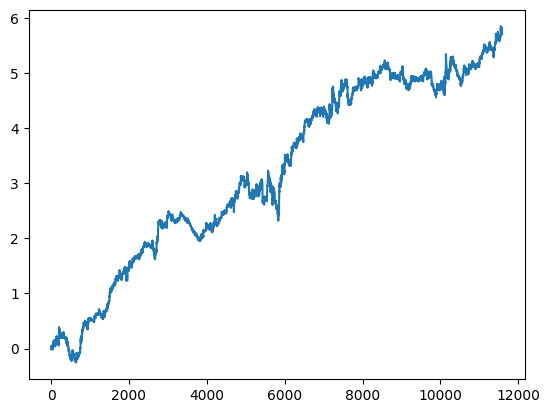

In [27]:
plt.plot(cum_ret)
sharpe = np.sqrt(252)*log_ret.mean()/log_ret.std() # YEARLY estimated sharpe
real_profit_fac = log_ret[log_ret>0].sum()/log_ret[log_ret<0].abs().sum()
sharpe, real_profit_fac

In [9]:
# Is this overfit? (i.e. does the optimization depend on data mining bias?)
# To test this you can do a monte carlo (in sample) permutation test
    # if the strategy actually finds patterns in the data, it should perform worse on random data
    # so create permutations of the data and see how the strategy does after being optimized on that data

In [28]:
# Shuffles the returns to make a new close
def get_perm(close: pd.Series):
    log_close = np.log(close)
    ret = log_close.diff().dropna().to_numpy()
    np.random.shuffle(ret)
    ret = np.concatenate(([0], ret))
    ret = pd.Series(ret).cumsum() + log_close.iloc[0]
    return np.exp(ret)

0
100
200
300
400
500
600
700
800
900


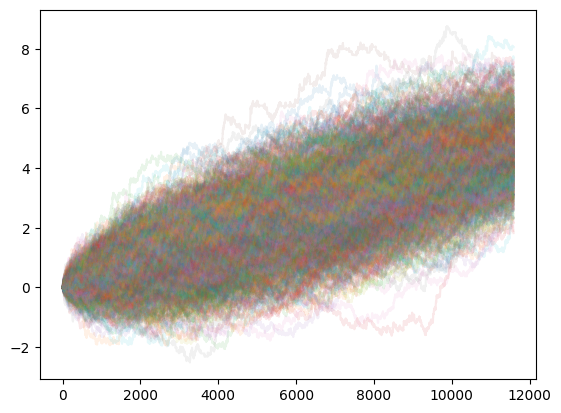

In [ ]:
plt.plot(cum_ret, color="black")

n_perm = 1000
n_better = 0
pfs = []
for i in range(n_perm):
    if (i%100 == 0): print(i)
    perm = get_perm(df["close"])
    fast_window, slow_window = optimize(perm)
    signal = strategy(perm, fast_window, slow_window)
    log_ret: pd.Series = np.log(perm).diff()*signal.shift(1)
    cum_ret = log_ret.cumsum()
    profit_fac = log_ret[log_ret>0].sum()/log_ret[log_ret<0].abs().sum()
    if profit_fac > real_profit_fac:
        n_better += 1
    pfs.append(profit_fac)
    plt.plot(cum_ret, alpha=0.05)
plt.show()

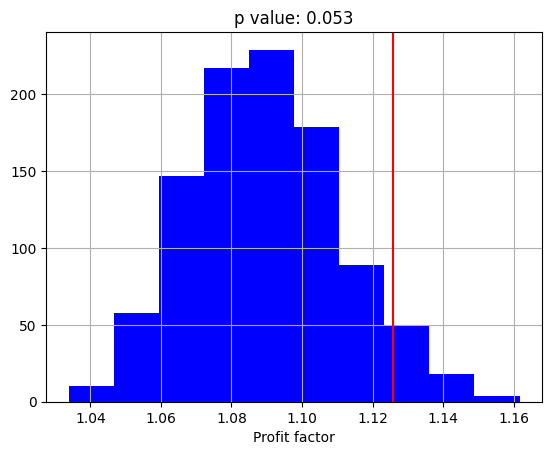

In [ ]:
# Hmmm, not so good
pd.Series(pfs).hist(color="blue", label="Permutations")
plt.axvline(real_profit_fac, color="red")
plt.xlabel("Profit factor")
plt.title(f"p value: {n_better/1000}")
plt.show()